In [1]:
# ============================================================
# Project root & path handling
# ------------------------------------------------------------
# Default: working directory
# ============================================================

from pathlib import Path
import os
import json
import numpy as np
import pandas as pd

# Determine project root
PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", ".")).expanduser().resolve()

# Convenience function for building repo-relative paths
def p(rel_path):
    """
    Build an absolute path from a path relative to the project root.
    """
    return PROJECT_ROOT / rel_path

print("PROJECT_ROOT set to:", PROJECT_ROOT)

PROJECT_ROOT set to: /net/bbi/vol1/home/mtejura/IGVF-cvfg-pillar-project


In [2]:
# ============================================================
# Create temporary and output directories 
# ============================================================

DATA_DIR = p("data")
TMP_DIR = p("tmp")
OUT_DIR = p("outputs")

TMP_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

In [7]:
import pandas as pd
controls_no_dup_REVEL_YP = pd.read_csv(OUT_DIR/"GeneSpecific_calibrations/controls_REVEL_GeneSpecific.csv")

/tmp/7649811.1.fowler-login.q/ipykernel_3256985/1713179913.py:2: DtypeWarning: Columns (4,48,49,50,78,94,107) have mixed types. Specify dtype option on import or set low_memory=False.
  controls_no_dup_REVEL_YP = pd.read_csv(OUT_DIR/"GeneSpecific_calibrations/controls_REVEL_GeneSpecific.csv")


In [8]:
import numpy as np

pathogenic = {"Pathogenic", "Likely pathogenic", "Likely Pathogenic","Pathogenic/Likely pathogenic"}
benign = {"Benign", "Likely benign", "Likely Benign","Benign/Likely benign"}

def collapse_path_ben(x):
    if pd.isna(x):
        return np.nan
    if x in pathogenic:
        return "Pathogenic"
    if x in benign:
        return "Benign"
    return np.nan


def gene_concordance(
    df,
    truth_col,
    pred_col,
    gene_col="Gene",
    uncertain_col = 'Class_REVEL'):
    tmp = df.copy()

    # Collapse truth / prediction
    tmp["truth_bin"] = tmp[truth_col].apply(collapse_path_ben)
    tmp["pred_bin"]  = tmp[pred_col].apply(collapse_path_ben)

    # Concordant
    tmp["concordant"] = (
        ((tmp["truth_bin"] == "Pathogenic") & (tmp["pred_bin"] == "Pathogenic")) |
        ((tmp["truth_bin"] == "Benign")     & (tmp["pred_bin"] == "Benign"))
    )

    # False negatives: Pathogenic → Benign
    tmp["FN"] = (
        (tmp["truth_bin"] == "Pathogenic") &
        (tmp["pred_bin"] == "Benign")
    )

    # False positives: Benign → Pathogenic
    tmp["FP"] = (
        (tmp["truth_bin"] == "Benign") &
        (tmp["pred_bin"] == "Pathogenic")
    )

    # Total discordance = FN + FP
    tmp["discordant"] = tmp["FN"] | tmp["FP"]

    # Uncertain
    tmp["uncertain"] = (
        tmp[uncertain_col] == "Uncertain"
    )

    return (
        tmp
        .groupby(gene_col)
        .agg(
            n_total=(gene_col, "size"),
            n_concordant=("concordant", "sum"),
            n_discordant=("discordant", "sum"),
            n_FN=("FN", "sum"),
            n_FP=("FP", "sum"),
            n_uncertain=("uncertain", "sum"),
        )
        .assign(
            concordance_pct=lambda x: 100 * x["n_concordant"] / x["n_total"],
            discordance_pct=lambda x: 100 * x["n_discordant"] / x["n_total"],
            FN_pct=lambda x: 100 * x["n_FN"] / x["n_total"],
            FP_pct=lambda x: 100 * x["n_FP"] / x["n_total"],
            uncertain_pct=lambda x: 100 * x["n_uncertain"] / x["n_total"],
        )
        .reset_index()
    )


In [9]:
gene_conc = gene_concordance(
    df=controls_no_dup_REVEL_YP,
    truth_col="clnsig_group_18_25",
    pred_col="Class_REVEL"
)


In [11]:
import numpy as np
import pandas as pd

df2 = controls_no_dup_REVEL_YP.copy()

df2["truth_bin"] = df2["clnsig_group_18_25"].apply(collapse_path_ben)
df2["pred_bin"]  = df2["Class_REVEL"].apply(collapse_path_ben)

# Strict discordance only: P↔B flips
df2["discordant"] = (
    ((df2["truth_bin"] == "Pathogenic") & (df2["pred_bin"] == "Benign")) |
    ((df2["truth_bin"] == "Benign")     & (df2["pred_bin"] == "Pathogenic"))
)

gene_stats = (
    df2
    .groupby("Gene")
    .agg(
        n_total=("Gene", "size"),
        n_discordant=("discordant", "sum")
    )
    .reset_index()
)

In [12]:
TOTAL_DISCORDANT = gene_stats["n_discordant"].sum()
TOTAL_VARIANTS   = gene_stats["n_total"].sum()

gene_stats["background_rate_loo"] = (
    (TOTAL_DISCORDANT - gene_stats["n_discordant"]) /
    (TOTAL_VARIANTS   - gene_stats["n_total"])
)

In [13]:
from scipy.stats import binomtest

gene_stats["p_value"] = gene_stats.apply(
    lambda r: binomtest(
        k=int(r["n_discordant"]),
        n=int(r["n_total"]),
        p=r["background_rate_loo"],
        alternative="greater"
    ).pvalue,
    axis=1
)

In [14]:
from statsmodels.stats.multitest import multipletests

gene_stats["q_value"] = multipletests(
    gene_stats["p_value"],
    method="fdr_bh"
)[1]


In [15]:
gene_stats["discordance_rate"] = (
    gene_stats["n_discordant"] / gene_stats["n_total"]
)

gene_stats["excess_discordance"] = (
    gene_stats["discordance_rate"] - gene_stats["background_rate_loo"]
)


In [16]:
OUTLIERS = gene_stats[
    (gene_stats["n_total"] >= 10) &
    (gene_stats["q_value"] < 0.05) &
    (gene_stats["excess_discordance"] > 0)
].sort_values("excess_discordance", ascending=False)

In [17]:
OUTLIERS

,Gene,n_total,n_discordant,background_rate_loo,p_value,q_value,discordance_rate,excess_discordance
34,TP53,144,10,0.005653,1.283953e-08,5.007418e-07,0.069444,0.063792
12,F9,252,7,0.006014,9.332805e-04,1.819897e-02,0.027778,0.021763
37,VHL,401,8,0.006004,3.286756e-03,4.272782e-02,0.019950,0.013946


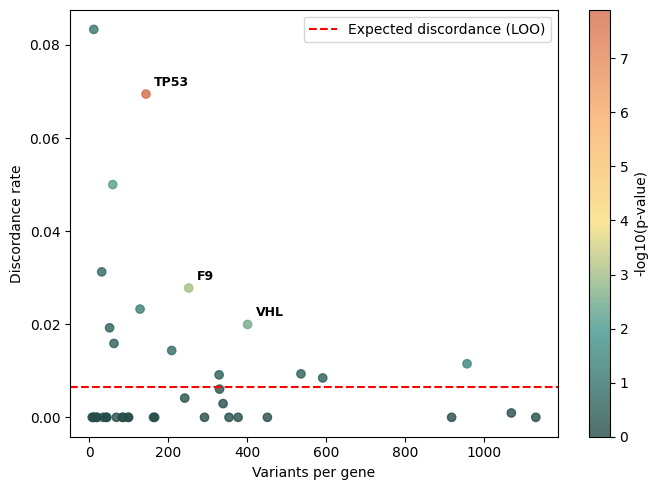

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

EMERALD_SEQ = LinearSegmentedColormap.from_list(
    "emerald_seq",
    [
        "#264D49",  
        "#43978D",  
        "#F9E07F",  
        "#F9AD6A",  
        "#D46C4E",
    ]
)

gene_stats["neglog10_p"] = -np.log10(gene_stats["p_value"])

# Define which genes get labels
label_genes = gene_stats[
    (gene_stats["q_value"] < 0.05) &
    (gene_stats["n_total"] >= 10)
]

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    gene_stats["n_total"],
    gene_stats["discordance_rate"],
    c=gene_stats["neglog10_p"],
    cmap= EMERALD_SEQ,
    alpha=0.8
)

# Background / expected line
ax.axhline(
    gene_stats["background_rate_loo"].mean(),
    color="red",
    linestyle="--",
    label="Expected discordance (LOO)"
)

# Label only significant genes
for _, row in label_genes.iterrows():
    ax.annotate(
        row["Gene"],
        (row["n_total"], row["discordance_rate"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold"
    )

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(p-value)")

ax.set_xlabel("Variants per gene")
ax.set_ylabel("Discordance rate")
ax.legend()
plt.tight_layout()
plt.savefig("clinvar_discordance_per_gene_011126.png", dpi=300, bbox_inches="tight")
plt.show()